# NLP Final Term Project — Group 02, Section B**Domain:** AI-generated content detection (binary: human vs machine)**Models:** BERT (`bert-base-uncased`), BERT variation (`microsoft/deberta-v3-base`), and avalidation-weighted soft-vote ensemble of the two.**Datasets:** Dataset 1 = DAIGT V2 Train Dataset. Dataset 2 = HC3 (Human ChatGPT Comparison Corpus).**Continuity with the midterm.** The classical models (Naive Bayes, Logistic Regression, SupportVector Machine) were evaluated at midterm on a balanced 3,000-per-class sample of each dataset,split 80/20 with `random_state=42` and stratification. This notebook rebuilds that identical splitand scores the transformers on the identical 1,200-row test set, so that the final combined tablecompares models rather than comparing splits. Section 1 verifies this by re-deriving all twenty-fourmidterm numbers from scratch and asserting they match.

## Section 0 — EnvironmentCache locations are pinned before any HuggingFace import. The root filesystem on this machine hasunder 4 GB free, so the model cache and the training checkpoints are both directed to a volume withroom. `HF_HUB_DISABLE_SYMLINKS` is required because that volume is NTFS, which has no POSIX symlinks.

In [1]:
import os
os.environ['HF_HOME'] = '/media/filwel/MLProject1/hf_cache'
os.environ['HF_HUB_DISABLE_SYMLINKS'] = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
print('HF_HOME =', os.environ['HF_HOME'])

HF_HOME = /media/filwel/MLProject1/hf_cache


In [2]:
import gc, json, re, shutil, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, EarlyStoppingCallback, DataCollatorWithPadding, set_seed)
from datasets import Dataset
warnings.filterwarnings('ignore')

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print('torch          ', torch.__version__)
print('transformers   ', transformers.__version__)
print('cuda available ', torch.cuda.is_available())
assert torch.cuda.is_available(), 'CUDA unavailable, halting'
print('device         ', torch.cuda.get_device_name(0))
print('capability     ', torch.cuda.get_device_capability(0))
print('bf16 supported ', torch.cuda.is_bf16_supported())
assert torch.cuda.is_bf16_supported(), 'bf16 unsupported, halting'
free_b, total_b = torch.cuda.mem_get_info()
print('VRAM free/total %.2f / %.2f GiB' % (free_b/1024**3, total_b/1024**3))

/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Project /.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch           2.11.0+cu128
transformers    4.57.6
cuda available  True
device          NVIDIA GeForce RTX 3060 Ti
capability      (8, 6)
bf16 supported  True
VRAM free/total 5.84 / 7.65 GiB


In [3]:
PROJECT_DIR = Path('/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Project ')
FINAL_DIR   = Path('/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final')
WORK_DIR    = FINAL_DIR / 'work'
RESULTS_DIR = FINAL_DIR / 'results'
PROBS_DIR   = FINAL_DIR / 'probs'
FIG_DIR     = FINAL_DIR / 'figures'
CKPT_DIR    = Path('/media/filwel/MLProject1/nlp_final_ckpt')
for d in (WORK_DIR, RESULTS_DIR, PROBS_DIR, FIG_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

SAMPLE_PER_CLASS = 3000
MAX_LEN          = 128
EPOCHS           = 5
WARMUP_RATIO     = 0.1
PATIENCE         = 2
SEED             = 42

MODELS = {'BERT': 'bert-base-uncased', 'DeBERTa': 'microsoft/deberta-v3-base'}
GRID = [(2e-5,16,0.01), (3e-5,16,0.01), (2e-5,32,0.01), (3e-5,32,0.01),
        (2e-5,16,0.1),  (3e-5,16,0.1),  (2e-5,32,0.1),  (3e-5,32,0.1)]
DATASETS = ['D1', 'D2']

QUICK = os.environ.get('NLP_QUICK') == '1'
if QUICK:
    GRID = GRID[:2]
    EPOCHS = 1
    RESULTS_DIR = FINAL_DIR / 'results_quick'; RESULTS_DIR.mkdir(exist_ok=True)
    PROBS_DIR   = FINAL_DIR / 'probs_quick';   PROBS_DIR.mkdir(exist_ok=True)
    print('QUICK VALIDATION MODE: %d configs, %d epoch, results isolated in *_quick/' % (len(GRID), EPOCHS))

N_EXPECTED_RUNS = len(DATASETS) * len(MODELS) * len(GRID)
print('configurations per model per dataset:', len(GRID))
print('total fine-tuning runs:', len(GRID) * len(MODELS) * len(DATASETS))

configurations per model per dataset: 8
total fine-tuning runs: 32


## Section 1 — Data, split reconstruction, and midterm verificationThe midterm pipeline is reproduced exactly: load, balance to 3,000 per class with `seed=42`, applythe midterm text cleaning, then split 80/20 stratified with `random_state=42`.Two things then happen that the midterm did not do.First, the split is recomputed on the dataframe **index** rather than on a text column. With the same`random_state` and the same stratification array, scikit-learn's partition does not depend on what`X` contains, so index splitting recovers the identical partition while leaving both the raw textand the cleaned text reachable. The cell below asserts order-sensitive equality between the two.Second, a validation set is carved out of the training portion only (4,320 train / 480 validation).The 1,200-row test set is never touched during training or model selection. Early stopping readsvalidation; the ensemble weight is tuned on validation; test is scored exactly once per run.**Why the transformers receive raw text.** The midterm cleaning lowercases, deletes everynon-alphabetic character, removes stopwords, and lemmatises. Punctuation rhythm, casing, andfunction-word usage are among the strongest signals for distinguishing machine-generated text, andthat pipeline destroys all three. Applying it to a transformer would discard the information themodel exists to exploit. The two model families therefore see different inputs, each appropriate toits class, and this is stated in the report.

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 1]
    return ' '.join(tokens)

def balance(df, n, seed=42):
    parts = []
    for value in sorted(df['label'].unique()):
        subset = df[df['label'] == value]
        parts.append(subset.sample(n=min(n, len(subset)), random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def load_D1():
    raw = pd.read_csv(PROJECT_DIR / 'daigt.csv')
    df = raw[['text', 'label']].dropna()
    df['label'] = df['label'].astype(int)
    del raw; gc.collect()
    return balance(df, SAMPLE_PER_CLASS)

def load_D2():
    raw = pd.read_json(PROJECT_DIR / 'hc3.jsonl', lines=True)
    human = raw[['human_answers']].explode('human_answers').rename(columns={'human_answers': 'text'})
    human['label'] = 0
    bot = raw[['chatgpt_answers']].explode('chatgpt_answers').rename(columns={'chatgpt_answers': 'text'})
    bot['label'] = 1
    df = pd.concat([human, bot], ignore_index=True).dropna()
    df['text'] = df['text'].astype(str)
    del raw, human, bot; gc.collect()
    return balance(df, SAMPLE_PER_CLASS)

LOADERS = {'D1': load_D1, 'D2': load_D2}
DATASET_NAMES = {'D1': 'DAIGT V2', 'D2': 'HC3'}
print('loaders ready')

loaders ready


In [5]:
MIDTERM_RECORDED = {
 ('D1','Naive Bayes','BoW'):           (0.9567,0.9580,0.9567,0.9566),
 ('D1','Naive Bayes','TF-IDF'):        (0.9508,0.9515,0.9508,0.9508),
 ('D1','Logistic Regression','BoW'):   (0.9825,0.9826,0.9825,0.9825),
 ('D1','Logistic Regression','TF-IDF'):(0.9758,0.9761,0.9758,0.9758),
 ('D1','Support Vector Machine','BoW'):(0.9775,0.9776,0.9775,0.9775),
 ('D1','Support Vector Machine','TF-IDF'):(0.9875,0.9877,0.9875,0.9875),
 ('D2','Naive Bayes','BoW'):           (0.8583,0.8587,0.8583,0.8583),
 ('D2','Naive Bayes','TF-IDF'):        (0.8275,0.8387,0.8275,0.8261),
 ('D2','Logistic Regression','BoW'):   (0.9333,0.9346,0.9333,0.9333),
 ('D2','Logistic Regression','TF-IDF'):(0.8925,0.8926,0.8925,0.8925),
 ('D2','Support Vector Machine','BoW'):(0.9117,0.9132,0.9117,0.9116),
 ('D2','Support Vector Machine','TF-IDF'):(0.9083,0.9084,0.9083,0.9083),
}

def weighted_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return acc, pre, rec, f1
print('midterm reference table loaded:', len(MIDTERM_RECORDED), 'entries')

midterm reference table loaded: 12 entries


In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

DATA, SPLITS, MIDTERM_ROWS, CLASSICAL_PRED, TEST_ORDER = {}, {}, {}, {}, {}
all_match = True

for tag in DATASETS:
    df = LOADERS[tag]()
    df['clean_text'] = df['text'].apply(preprocess)

    Xtr_lit, Xte_lit, ytr_lit, yte_lit = train_test_split(
        df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
    idx_tr, idx_te, _, _ = train_test_split(
        df.index.values, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'].values)

    assert np.array_equal(np.asarray(Xtr_lit.index), idx_tr), tag + ': train split diverged'
    assert np.array_equal(np.asarray(Xte_lit.index), idx_te), tag + ': test split diverged'

    sub_tr, sub_val = train_test_split(idx_tr, test_size=0.1, random_state=42,
                                       stratify=df.loc[idx_tr, 'label'].values)

    for rep, Vec in (('BoW', CountVectorizer), ('TF-IDF', TfidfVectorizer)):
        vec = Vec()
        Xtr, Xte = vec.fit_transform(Xtr_lit), vec.transform(Xte_lit)
        for name, build in (('Naive Bayes', lambda: MultinomialNB()),
                            ('Logistic Regression', lambda: LogisticRegression(max_iter=1000)),
                            ('Support Vector Machine', lambda: LinearSVC())):
            clf = build(); clf.fit(Xtr, ytr_lit)
            yhat = clf.predict(Xte)
            CLASSICAL_PRED[(tag, name, rep)] = np.asarray(yhat)
            got = weighted_metrics(yte_lit, yhat)
            exp = MIDTERM_RECORDED[(tag, name, rep)]
            ok = all(abs(round(g, 4) - e) <= 1e-4 for g, e in zip(got, exp))
            all_match &= ok
            MIDTERM_ROWS[(tag, name, rep)] = tuple(round(g, 4) for g in got)
            print('%-8s %-24s %-7s %s  %s' % (tag, name, rep,
                  tuple(round(g,4) for g in got), 'MATCH' if ok else 'MISMATCH'))
        del vec, Xtr, Xte

    DATA[tag] = df[['text', 'label', 'clean_text']].copy()
    SPLITS[tag] = {'train': sub_tr, 'val': sub_val, 'test': idx_te}
    TEST_ORDER[tag] = np.asarray(Xte_lit.index)
    print('%s split  train=%d  val=%d  test=%d  test per class=%s\n' % (
        tag, len(sub_tr), len(sub_val), len(idx_te),
        pd.Series(df.loc[idx_te, 'label'].values).value_counts().sort_index().to_dict()))
    del df; gc.collect()

assert all_match, 'midterm reproduction failed, the combined table would be invalid'
print('=' * 70)
print('VERIFIED: all 24 midterm numbers reproduced, split is identical to the midterm split')
print('=' * 70)

D1       Naive Bayes              BoW     (0.9567, 0.958, 0.9567, 0.9566)  MATCH


D1       Logistic Regression      BoW     (0.9825, 0.9826, 0.9825, 0.9825)  MATCH
D1       Support Vector Machine   BoW     (0.9775, 0.9776, 0.9775, 0.9775)  MATCH


D1       Naive Bayes              TF-IDF  (0.9508, 0.9515, 0.9508, 0.9508)  MATCH


D1       Logistic Regression      TF-IDF  (0.9758, 0.9761, 0.9758, 0.9758)  MATCH
D1       Support Vector Machine   TF-IDF  (0.9875, 0.9877, 0.9875, 0.9875)  MATCH
D1 split  train=4320  val=480  test=1200  test per class={0: 600, 1: 600}



D2       Naive Bayes              BoW     (0.8583, 0.8587, 0.8583, 0.8583)  MATCH


D2       Logistic Regression      BoW     (0.9333, 0.9346, 0.9333, 0.9333)  MATCH
D2       Support Vector Machine   BoW     (0.9117, 0.9132, 0.9117, 0.9116)  MATCH


D2       Naive Bayes              TF-IDF  (0.8275, 0.8387, 0.8275, 0.8261)  MATCH


D2       Logistic Regression      TF-IDF  (0.8925, 0.8926, 0.8925, 0.8925)  MATCH
D2       Support Vector Machine   TF-IDF  (0.9083, 0.9084, 0.9083, 0.9083)  MATCH
D2 split  train=4320  val=480  test=1200  test per class={0: 600, 1: 600}



VERIFIED: all 24 midterm numbers reproduced, split is identical to the midterm split


## Section 2 — Tokenisation and sequence-length diagnosticsMaximum sequence length is fixed at 128 by the project specification. DAIGT essays average roughly2,200 characters, which is well beyond that, so the figure and table below quantify how much of eachdocument actually reaches the model. This is the leading limitation of the study and is reportedrather than worked around.

In [7]:
TOKENIZERS, TOKENIZED = {}, {}

def get_tokenizer(model_key):
    if model_key not in TOKENIZERS:
        TOKENIZERS[model_key] = AutoTokenizer.from_pretrained(MODELS[model_key])
    return TOKENIZERS[model_key]

def normalise(t):
    return re.sub(r'\s+', ' ', str(t)).strip()

def get_tokenized(tag, model_key, max_len=MAX_LEN):
    cache_key = (tag, model_key, max_len)
    if cache_key in TOKENIZED:
        return TOKENIZED[cache_key]
    tok = get_tokenizer(model_key)
    df = DATA[tag]
    parts = {}
    for split, idx in SPLITS[tag].items():
        sub = df.loc[idx]
        ds = Dataset.from_dict({'text': [normalise(t) for t in sub['text']],
                                'labels': [int(v) for v in sub['label']]})
        ds = ds.map(lambda b: tok(b['text'], truncation=True, max_length=max_len),
                    batched=True, remove_columns=['text'])
        parts[split] = ds
    TOKENIZED[cache_key] = parts
    return parts
print('tokenisation helpers ready')

tokenisation helpers ready


Token indices sequence length is longer than the specified maximum sequence length for this model (541 > 512). Running this sequence through the model will result in indexing errors


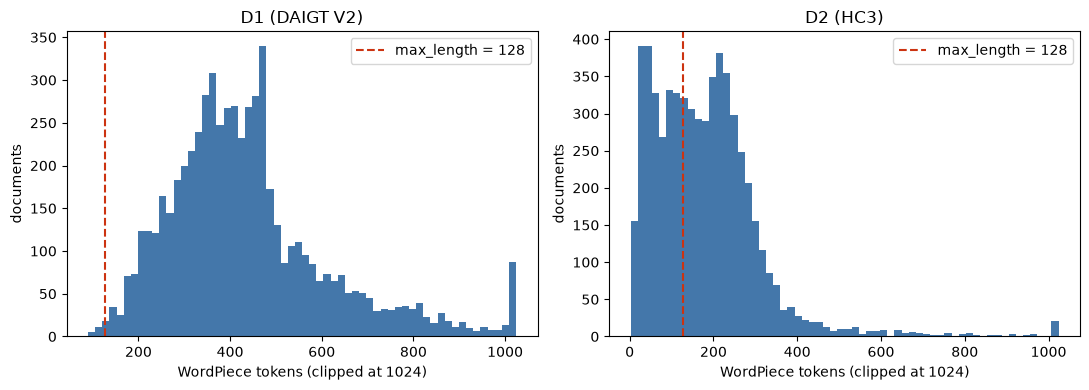

,dataset,name,median,mean,p95,max,pct_truncated,median_pct_kept
0,D1,DAIGT V2,409,439.8,803,1759,99.6,31.3
1,D2,HC3,165,181.9,376,8753,61.1,77.6


In [8]:
rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tag in zip(axes, DATASETS):
    tok = get_tokenizer('BERT')
    texts = [normalise(t) for t in DATA[tag]['text']]
    lens = np.array([len(tok(t, truncation=False)['input_ids']) for t in texts])
    ax.hist(np.clip(lens, 0, 1024), bins=60, color='#4477aa', edgecolor='none')
    ax.axvline(MAX_LEN, color='#cc3311', linestyle='--', label='max_length = %d' % MAX_LEN)
    ax.set_title('%s (%s)' % (tag, DATASET_NAMES[tag]))
    ax.set_xlabel('WordPiece tokens (clipped at 1024)'); ax.set_ylabel('documents'); ax.legend()
    rows.append({'dataset': tag, 'name': DATASET_NAMES[tag], 'median': int(np.median(lens)),
                 'mean': round(float(lens.mean()), 1), 'p95': int(np.percentile(lens, 95)),
                 'max': int(lens.max()),
                 'pct_truncated': round(float((lens > MAX_LEN).mean() * 100), 1),
                 'median_pct_kept': round(float(np.median(np.minimum(lens, MAX_LEN) / lens) * 100), 1)})
    del texts, lens; gc.collect()
plt.tight_layout(); plt.savefig(FIG_DIR / 'token_length_distribution.png', dpi=150)
plt.show()
LENGTH_STATS = pd.DataFrame(rows)
LENGTH_STATS.to_csv(WORK_DIR / 'length_stats.csv', index=False)
display(LENGTH_STATS)

## Section 3 — Run harness with checkpointingThe sweep is thirty-two fine-tuning runs on a desktop GPU that also drives the display, so it has tosurvive interruption. Three independent mechanisms provide that.**Run-level resumption.** Every finished run writes a metrics JSON keyed by its full configuration.On re-entry, a run whose JSON already exists returns immediately without touching the GPU. Re-runningthe whole sweep cell after a completed pass therefore costs seconds, not hours.**Within-run resumption.** The `Trainer` saves a checkpoint at the end of every epoch into a directoryprivate to that run. If the process dies mid-run, the next invocation detects the surviving`checkpoint-*` directories and passes `resume_from_checkpoint`, so training restarts from the lastcompleted epoch with its optimizer state, learning-rate schedule, and early-stopping counters intactrather than starting over.**Atomic writes.** Metrics and probability arrays are written to a temporary file and then moved intoplace with `os.replace`, which is atomic on a single filesystem. A process killed during the writeleaves the temporary file behind and no partial JSON, so a half-written run can never be mistaken fora completed one on the next pass.The checkpoint directory is deleted only after the JSON has landed, in that order. Deleting firstwould create a window in which the run is neither resumable nor recorded. A `save_total_limit` of twobounds the cost at roughly 4 GB for a DeBERTa run, and only one run is ever active.A ledger file records the outcome of each run as it completes, giving a durable record of sweepprogress that survives a kernel restart.

In [9]:
def atomic_write_json(path, obj):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    with open(tmp, 'w') as fh:
        json.dump(obj, fh, indent=2)
        fh.flush(); os.fsync(fh.fileno())
    os.replace(tmp, path)

def atomic_write_npz(path, **arrays):
    path = Path(path)
    tmp = path.with_suffix('.npz.tmp')
    with open(tmp, 'wb') as fh:
        np.savez(fh, **arrays)
        fh.flush(); os.fsync(fh.fileno())
    os.replace(tmp, path)

def run_key(tag, model_key, lr, bs, wd, seed, max_len, epochs=None):
    base = '%s_%s_lr%g_bs%d_wd%g_s%d' % (tag, model_key, lr, bs, wd, seed)
    if max_len != MAX_LEN:
        base += '_len%d' % max_len
    if epochs is not None and epochs != EPOCHS:
        base += '_ep%d' % epochs
    return base

def find_checkpoint(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.exists():
        return None
    cks = [p for p in run_dir.glob('checkpoint-*') if (p / 'trainer_state.json').exists()]
    if not cks:
        return None
    return str(max(cks, key=lambda p: int(p.name.split('-')[1])))

def ledger_append(entry):
    path = WORK_DIR / 'sweep_ledger.json'
    log = json.load(open(path)) if path.exists() else []
    log = [e for e in log if e['key'] != entry['key']] + [entry]
    atomic_write_json(path, log)

def cleanup_stale_tmp():
    n = 0
    for d in (RESULTS_DIR, PROBS_DIR):
        for p in list(d.glob('*.tmp')):
            p.unlink(); n += 1
    if n:
        print('removed %d stale temporary file(s) from an interrupted write' % n)
cleanup_stale_tmp()
print('checkpointing helpers ready')

checkpointing helpers ready


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc, pre, rec, f1 = weighted_metrics(labels, preds)
    return {'accuracy': acc, 'precision': pre, 'recall': rec, 'f1': f1}

def run_one(tag, model_key, lr, bs, wd, seed=SEED, epochs=EPOCHS, max_len=MAX_LEN, verbose=True):
    key = run_key(tag, model_key, lr, bs, wd, seed, max_len, epochs)
    jpath = RESULTS_DIR / (key + '.json')
    ppath = PROBS_DIR / (key + '.npz')
    if jpath.exists() and ppath.exists():
        rec = json.load(open(jpath))
        if verbose:
            print('[skip] %-42s test_f1=%.4f' % (key, rec['test']['f1']))
        return rec
    if jpath.exists() and not ppath.exists():
        print('[repair] %s has metrics but no probability array, re-running' % key)
        jpath.unlink()

    run_dir = CKPT_DIR / key
    resume = find_checkpoint(run_dir)
    if resume and verbose:
        print('[resume] %s from %s' % (key, Path(resume).name))

    parts = get_tokenized(tag, model_key, max_len)
    tok = get_tokenizer(model_key)

    attempts = [(bs, 1)]
    if bs > 16:
        attempts.append((bs // 2, 2))
    last_oom = None
    for attempt_i, (per_device_bs, accum) in enumerate(attempts):
      try:
        set_seed(seed)
        model = AutoModelForSequenceClassification.from_pretrained(MODELS[model_key], num_labels=2)
        args = TrainingArguments(
            output_dir=str(run_dir),
            learning_rate=lr,
            per_device_train_batch_size=per_device_bs,
            gradient_accumulation_steps=accum,
            per_device_eval_batch_size=64,
            weight_decay=wd,
            num_train_epochs=epochs,
            warmup_ratio=WARMUP_RATIO,
            lr_scheduler_type='linear',
            optim='adamw_torch',
            bf16=True,
            eval_strategy='epoch',
            save_strategy='epoch',
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model='eval_f1',
            greater_is_better=True,
            logging_steps=50,
            seed=seed,
            data_seed=seed,
            dataloader_num_workers=0,
            report_to='none',
            disable_tqdm=not verbose,
        )
        trainer = Trainer(
            model=model, args=args,
            train_dataset=parts['train'], eval_dataset=parts['val'],
            data_collator=DataCollatorWithPadding(tok),
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
        )
        torch.cuda.reset_peak_memory_stats()
        t0 = time.time()
        trainer.train(resume_from_checkpoint=resume)
        train_secs = time.time() - t0
        break
      except torch.cuda.OutOfMemoryError as exc:
        last_oom = exc
        print('    OOM at per-device batch %d, falling back' % per_device_bs)
        try:
            del trainer
        except NameError:
            pass
        try:
            del model
        except NameError:
            pass
        gc.collect(); torch.cuda.empty_cache()
        shutil.rmtree(run_dir, ignore_errors=True)
        resume = None
        if attempt_i == len(attempts) - 1:
            raise

    out = {'key': key, 'dataset': tag, 'dataset_name': DATASET_NAMES[tag], 'model': model_key,
           'checkpoint': MODELS[model_key], 'lr': lr, 'batch_size': bs,
           'per_device_batch_size': per_device_bs, 'gradient_accumulation_steps': accum,
           'weight_decay': wd, 'seed': seed, 'max_len': max_len, 'epochs_requested': epochs,
           'train_seconds': round(train_secs, 1),
           'epochs_run': int(trainer.state.epoch or 0),
           'best_checkpoint_metric': trainer.state.best_metric,
           'peak_vram_gib': round(torch.cuda.max_memory_allocated() / 1024**3, 2),
           'resumed': bool(resume)}

    probs = {}
    for split in ('val', 'test'):
        pred = trainer.predict(parts[split])
        raw = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
        logits = torch.tensor(raw, dtype=torch.float32)
        p = torch.softmax(logits, dim=-1).numpy()
        y = np.asarray(pred.label_ids)
        acc, pre, rec, f1 = weighted_metrics(y, p.argmax(1))
        out[split] = {'accuracy': round(acc,4), 'precision': round(pre,4),
                      'recall': round(rec,4), 'f1': round(f1,4)}
        out[split + '_confusion'] = confusion_matrix(y, p.argmax(1)).tolist()
        _, _, mf1, _ = precision_recall_fscore_support(y, p.argmax(1), average='macro', zero_division=0)
        out[split + '_macro_f1'] = round(float(mf1), 4)
        probs['%s_probs' % split] = p
        probs['%s_labels' % split] = y

    atomic_write_npz(PROBS_DIR / (key + '.npz'), **probs)
    atomic_write_json(jpath, out)
    ledger_append({'key': key, 'test_f1': out['test']['f1'], 'val_f1': out['val']['f1'],
                   'train_seconds': out['train_seconds'], 'epochs_run': out['epochs_run']})

    del trainer, model; gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    shutil.rmtree(run_dir, ignore_errors=True)

    if verbose:
        print('[done] %-42s val_f1=%.4f test_f1=%.4f  %.1f min  peak %.2f GiB' % (
            key, out['val']['f1'], out['test']['f1'], train_secs/60, out['peak_vram_gib']))
    return out
print('run_one ready')

run_one ready


## Section 4 — Full hyperparameter sweepEight configurations for each of two models on each of two datasets, thirty-two runs. BERT runsfirst, so that an interruption still leaves one complete model family. Because every finished run isrecorded on disk, this cell is safe to re-run: it resumes wherever the previous pass stopped.

In [11]:
SWEEP_START = time.time()
total = len(DATASETS) * len(MODELS) * len(GRID)
done = 0
for tag in DATASETS:
    for model_key in ('BERT', 'DeBERTa'):
        for lr, bs, wd in GRID:
            done += 1
            print('--- run %d/%d  %s %s lr=%g bs=%d wd=%g ---' % (done, total, tag, model_key, lr, bs, wd))
            run_one(tag, model_key, lr, bs, wd)
            elapsed = time.time() - SWEEP_START
            if done:
                print('    elapsed %.1f min, projected remaining %.1f min\n' % (
                    elapsed/60, elapsed/done*(total-done)/60))
print('sweep complete in %.2f hours' % ((time.time()-SWEEP_START)/3600))

--- run 1/32  D1 BERT lr=2e-05 bs=16 wd=0.01 ---
[skip] D1_BERT_lr2e-05_bs16_wd0.01_s42            test_f1=0.9842
    elapsed 0.0 min, projected remaining 0.0 min

--- run 2/32  D1 BERT lr=3e-05 bs=16 wd=0.01 ---
[skip] D1_BERT_lr3e-05_bs16_wd0.01_s42            test_f1=0.9833
    elapsed 0.0 min, projected remaining 0.0 min

--- run 3/32  D1 BERT lr=2e-05 bs=32 wd=0.01 ---
[skip] D1_BERT_lr2e-05_bs32_wd0.01_s42            test_f1=0.9808
    elapsed 0.0 min, projected remaining 0.0 min

--- run 4/32  D1 BERT lr=3e-05 bs=32 wd=0.01 ---
[skip] D1_BERT_lr3e-05_bs32_wd0.01_s42            test_f1=0.9833
    elapsed 0.0 min, projected remaining 0.0 min

--- run 5/32  D1 BERT lr=2e-05 bs=16 wd=0.1 ---
[skip] D1_BERT_lr2e-05_bs16_wd0.1_s42             test_f1=0.9800
    elapsed 0.0 min, projected remaining 0.0 min

--- run 6/32  D1 BERT lr=3e-05 bs=16 wd=0.1 ---
[skip] D1_BERT_lr3e-05_bs16_wd0.1_s42             test_f1=0.9825
    elapsed 0.0 min, projected remaining 0.0 min

--- run 7/32  D1 B

[skip] D2_BERT_lr3e-05_bs32_wd0.01_s42            test_f1=0.9783
    elapsed 0.0 min, projected remaining 0.0 min

--- run 21/32  D2 BERT lr=2e-05 bs=16 wd=0.1 ---


[skip] D2_BERT_lr2e-05_bs16_wd0.1_s42             test_f1=0.9875
    elapsed 0.0 min, projected remaining 0.0 min

--- run 22/32  D2 BERT lr=3e-05 bs=16 wd=0.1 ---


[skip] D2_BERT_lr3e-05_bs16_wd0.1_s42             test_f1=0.9850
    elapsed 0.0 min, projected remaining 0.0 min

--- run 23/32  D2 BERT lr=2e-05 bs=32 wd=0.1 ---
[skip] D2_BERT_lr2e-05_bs32_wd0.1_s42             test_f1=0.9867
    elapsed 0.0 min, projected remaining 0.0 min

--- run 24/32  D2 BERT lr=3e-05 bs=32 wd=0.1 ---
[skip] D2_BERT_lr3e-05_bs32_wd0.1_s42             test_f1=0.9867
    elapsed 0.0 min, projected remaining 0.0 min

--- run 25/32  D2 DeBERTa lr=2e-05 bs=16 wd=0.01 ---
[skip] D2_DeBERTa_lr2e-05_bs16_wd0.01_s42         test_f1=0.9925
    elapsed 0.0 min, projected remaining 0.0 min

--- run 26/32  D2 DeBERTa lr=3e-05 bs=16 wd=0.01 ---
[skip] D2_DeBERTa_lr3e-05_bs16_wd0.01_s42         test_f1=0.9917
    elapsed 0.0 min, projected remaining 0.0 min

--- run 27/32  D2 DeBERTa lr=2e-05 bs=32 wd=0.01 ---
[skip] D2_DeBERTa_lr2e-05_bs32_wd0.01_s42         test_f1=0.9967
    elapsed 0.0 min, projected remaining 0.0 min

--- run 28/32  D2 DeBERTa lr=3e-05 bs=32 wd=0.01 ---


In [12]:
found = sorted(RESULTS_DIR.glob('*.json'))
sweep_runs = [json.load(open(p)) for p in found if '_len' not in p.stem]
sweep_runs = [r for r in sweep_runs if r['seed'] == SEED]
print('completed sweep runs on disk: %d (expected %d)' % (len(sweep_runs), N_EXPECTED_RUNS))
assert len(sweep_runs) == N_EXPECTED_RUNS, 'sweep incomplete, re-run the cell above to resume'
SWEEP = pd.DataFrame([{
    'dataset': r['dataset'], 'model': r['model'], 'lr': r['lr'], 'batch_size': r['batch_size'],
    'weight_decay': r['weight_decay'], 'epochs_run': r['epochs_run'],
    'val_f1': r['val']['f1'],
    'acc': r['test']['accuracy'], 'prec': r['test']['precision'],
    'rec': r['test']['recall'], 'f1': r['test']['f1'],
    'minutes': round(r['train_seconds']/60, 1), 'peak_vram': r['peak_vram_gib'],
} for r in sweep_runs])
SWEEP.to_csv(WORK_DIR / 'sweep_results.csv', index=False)
display(SWEEP.sort_values(['dataset','model','val_f1'], ascending=[True,True,False]))

completed sweep runs on disk: 32 (expected 32)


,dataset,model,lr,batch_size,weight_decay,epochs_run,val_f1,acc,prec,rec,f1,minutes,peak_vram
7,D1,BERT,0.00003,32,0.10,4,0.9854,0.9908,0.9909,0.9908,0.9908,1.7,2.96
5,D1,BERT,0.00003,16,0.10,4,0.9833,0.9825,0.9826,0.9825,0.9825,2.1,2.18
6,D1,BERT,0.00003,32,0.01,3,0.9812,0.9833,0.9833,0.9833,0.9833,1.3,2.96
4,D1,BERT,0.00003,16,0.01,5,0.9792,0.9833,0.9833,0.9833,0.9833,2.5,2.18
3,D1,BERT,0.00002,32,0.10,3,0.9750,0.9817,0.9817,0.9817,0.9817,1.3,2.96
0,D1,BERT,0.00002,16,0.01,5,0.9687,0.9842,0.9842,0.9842,0.9842,2.6,2.18
1,D1,BERT,0.00002,16,0.10,5,0.9667,0.9800,0.9803,0.9800,0.9800,1.1,2.18
2,D1,BERT,0.00002,32,0.01,5,0.9667,0.9808,0.9809,0.9808,0.9808,2.2,2.96
12,D1,DeBERTa,0.00003,16,0.01,4,0.9896,0.9933,0.9934,0.9933,0.9933,3.4,4.22
14,D1,DeBERTa,0.00003,32,0.01,4,0.9896,0.9942,0.9942,0.9942,0.9942,2.9,6.18


## Section 5 — EnsembleThe ensemble combines the two model families by averaging their predicted class probabilities. Themember configurations are chosen by **validation** weighted F1, and the mixing weight is likewisetuned on validation only. The test set is used once, after both choices are frozen.A weight sweep that terminates at zero or one means the ensemble has collapsed onto a single member.That is reported as such rather than presented as an ensemble result.

D1  members BERT=0.9908 DeBERTa=0.9933 -> ensemble test F1=0.9925  (w=0.35)


D2  members BERT=0.9875 DeBERTa=0.9992 -> ensemble test F1=0.9992  (w=0.00)   DEGENERATE: collapsed onto a single member


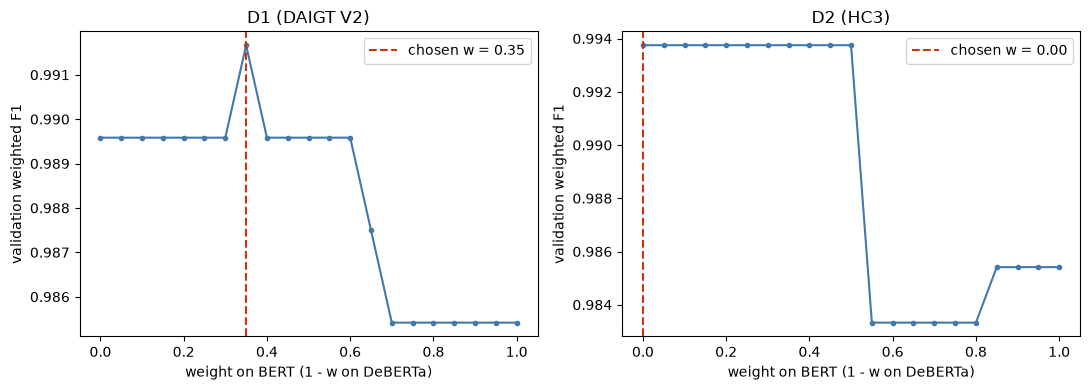

In [13]:
def load_probs(key):
    z = np.load(PROBS_DIR / (key + '.npz'))
    return {k: z[k] for k in z.files}

ENSEMBLE_ROWS, ENSEMBLE_DETAIL = {}, {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tag in zip(axes, DATASETS):
    picks = {}
    for mk in ('BERT', 'DeBERTa'):
        cand = [r for r in sweep_runs if r['dataset'] == tag and r['model'] == mk]
        picks[mk] = max(cand, key=lambda r: r['val']['f1'])
    pb, pd_ = load_probs(picks['BERT']['key']), load_probs(picks['DeBERTa']['key'])
    assert np.array_equal(pb['val_labels'], pd_['val_labels'])
    assert np.array_equal(pb['test_labels'], pd_['test_labels'])

    ws = np.arange(0, 1.0001, 0.05)
    val_f1 = [weighted_metrics(pb['val_labels'],
              (w*pb['val_probs'] + (1-w)*pd_['val_probs']).argmax(1))[3] for w in ws]
    best_w = float(ws[int(np.argmax(val_f1))])
    test_mix = best_w*pb['test_probs'] + (1-best_w)*pd_['test_probs']
    acc, pre, rec, f1 = weighted_metrics(pb['test_labels'], test_mix.argmax(1))
    ENSEMBLE_ROWS[tag] = (round(acc,4), round(pre,4), round(rec,4), round(f1,4))
    ENSEMBLE_DETAIL[tag] = {
        'weight_bert': best_w, 'weight_deberta': round(1-best_w, 2),
        'member_bert': picks['BERT']['key'], 'member_deberta': picks['DeBERTa']['key'],
        'member_bert_test_f1': picks['BERT']['test']['f1'],
        'member_deberta_test_f1': picks['DeBERTa']['test']['f1'],
        'ensemble_test_f1': round(f1,4),
        'degenerate': bool(best_w in (0.0, 1.0)),
        'confusion': confusion_matrix(pb['test_labels'], test_mix.argmax(1)).tolist()}

    ax.plot(ws, val_f1, marker='o', ms=3, color='#4477aa')
    ax.axvline(best_w, color='#cc3311', ls='--', label='chosen w = %.2f' % best_w)
    ax.set_title('%s (%s)' % (tag, DATASET_NAMES[tag]))
    ax.set_xlabel('weight on BERT (1 - w on DeBERTa)'); ax.set_ylabel('validation weighted F1'); ax.legend()

    print('%s  members BERT=%.4f DeBERTa=%.4f -> ensemble test F1=%.4f  (w=%.2f)%s' % (
        tag, picks['BERT']['test']['f1'], picks['DeBERTa']['test']['f1'], f1, best_w,
        '   DEGENERATE: collapsed onto a single member' if best_w in (0.0,1.0) else ''))
plt.tight_layout(); plt.savefig(FIG_DIR / 'ensemble_weight_sweep.png', dpi=150); plt.show()
atomic_write_json(WORK_DIR / 'ensemble_detail.json', ENSEMBLE_DETAIL)

## Section 6 — Seed robustnessThe sweep runs one seed. With eight configurations differing by fractions of a percent, some of theordering will be seed noise rather than a real effect. The winning configuration for each model anddataset is therefore repeated at two further seeds and reported as a mean with a range.At three seeds this supports descriptive statistics only. No significance test is applied, and noneshould be: the purpose is to show how wide the noise band is, so that a reader can judge whichdifferences in the main table are meaningful.

In [14]:
SEED_ROWS = []
for tag in DATASETS:
    for mk in ('BERT', 'DeBERTa'):
        cand = [r for r in sweep_runs if r['dataset'] == tag and r['model'] == mk]
        best = max(cand, key=lambda r: r['val']['f1'])
        f1s = [best['test']['f1']]
        for s in (123, 456):
            f1s.append(run_one(tag, mk, best['lr'], best['batch_size'], best['weight_decay'], seed=s)['test']['f1'])
        SEED_ROWS.append({'dataset': tag, 'model': mk,
                          'config': 'lr=%g bs=%d wd=%g' % (best['lr'], best['batch_size'], best['weight_decay']),
                          'seeds': '42/123/456', 'f1_values': [round(v,4) for v in f1s],
                          'mean_f1': round(float(np.mean(f1s)), 4),
                          'min_f1': round(float(np.min(f1s)), 4),
                          'max_f1': round(float(np.max(f1s)), 4),
                          'spread': round(float(np.max(f1s) - np.min(f1s)), 4)})
SEED_DF = pd.DataFrame(SEED_ROWS)
SEED_DF.to_csv(WORK_DIR / 'seed_robustness.csv', index=False)
display(SEED_DF)
print('\nWidest seed spread: %.4f F1. Differences in the main table smaller than this '
      'should not be read as real.' % SEED_DF['spread'].max())

[skip] D1_BERT_lr3e-05_bs32_wd0.1_s123            test_f1=0.9850
[skip] D1_BERT_lr3e-05_bs32_wd0.1_s456            test_f1=0.9641
[skip] D1_DeBERTa_lr3e-05_bs16_wd0.01_s123        test_f1=0.9900
[skip] D1_DeBERTa_lr3e-05_bs16_wd0.01_s456        test_f1=0.9917
[skip] D2_BERT_lr2e-05_bs16_wd0.1_s123            test_f1=0.9817
[skip] D2_BERT_lr2e-05_bs16_wd0.1_s456            test_f1=0.9867
[skip] D2_DeBERTa_lr3e-05_bs16_wd0.1_s123         test_f1=0.9967
[skip] D2_DeBERTa_lr3e-05_bs16_wd0.1_s456         test_f1=0.9983


,dataset,model,config,seeds,f1_values,mean_f1,min_f1,max_f1,spread
0,D1,BERT,lr=3e-05 bs=32 wd=0.1,42/123/456,"[0.9908, 0.985, 0.9641]",0.9800,0.9641,0.9908,0.0267
1,D1,DeBERTa,lr=3e-05 bs=16 wd=0.01,42/123/456,"[0.9933, 0.99, 0.9917]",0.9917,0.9900,0.9933,0.0033
2,D2,BERT,lr=2e-05 bs=16 wd=0.1,42/123/456,"[0.9875, 0.9817, 0.9867]",0.9853,0.9817,0.9875,0.0058
3,D2,DeBERTa,lr=3e-05 bs=16 wd=0.1,42/123/456,"[0.9992, 0.9967, 0.9983]",0.9981,0.9967,0.9992,0.0025



Widest seed spread: 0.0267 F1. Differences in the main table smaller than this should not be read as real.


## Section 7 — Result tables**Table 1** is the experiment table from the project specification: eight configurations per modelper dataset, plus the ensemble row.**Table 2** is the final combined table. The classical rows are the midterm results, recomputed herefrom scratch rather than copied. Each classical model is represented by its stronger textrepresentation; the transformer rows use the configuration with the best validation F1. Every cell inboth tables is read from a file on disk, none are entered by hand.

In [15]:
def fmt(v): return '%.4f' % v

t1 = []
for model_key in ('BERT', 'DeBERTa'):
    label = 'BERT' if model_key == 'BERT' else 'DeBERTa'
    for lr, bs, wd in GRID:
        row = {'Model': label, 'Learning Rate': '%.5f' % lr, 'Batch Size': bs, 'Weight Decay': wd}
        for tag in DATASETS:
            m = SWEEP[(SWEEP.dataset==tag) & (SWEEP.model==model_key) & (SWEEP.lr==lr) &
                      (SWEEP.batch_size==bs) & (SWEEP.weight_decay==wd)].iloc[0]
            for col, src in (('Acc','acc'), ('Prec','prec'), ('Rec','rec'), ('F1','f1')):
                row['%s %s' % (tag, col)] = fmt(m[src])
        t1.append(row)
erow = {'Model': 'ENSEMBLE', 'Learning Rate': '', 'Batch Size': '', 'Weight Decay': ''}
for tag in DATASETS:
    for col, v in zip(('Acc','Prec','Rec','F1'), ENSEMBLE_ROWS[tag]):
        erow['%s %s' % (tag, col)] = fmt(v)
t1.append(erow)
TABLE1 = pd.DataFrame(t1)
TABLE1.to_csv(FINAL_DIR / 'table1_experiments.csv', index=False)
display(TABLE1)

,Model,Learning Rate,Batch Size,Weight Decay,D1 Acc,D1 Prec,D1 Rec,D1 F1,D2 Acc,D2 Prec,D2 Rec,D2 F1
0,BERT,0.00002,16,0.01,0.9842,0.9842,0.9842,0.9842,0.9700,0.9717,0.9700,0.9700
1,BERT,0.00003,16,0.01,0.9833,0.9833,0.9833,0.9833,0.9842,0.9847,0.9842,0.9842
2,BERT,0.00002,32,0.01,0.9808,0.9809,0.9808,0.9808,0.9858,0.9862,0.9858,0.9858
3,BERT,0.00003,32,0.01,0.9833,0.9833,0.9833,0.9833,0.9783,0.9792,0.9783,0.9783
4,BERT,0.00002,16,0.1,0.9800,0.9803,0.9800,0.9800,0.9875,0.9877,0.9875,0.9875
5,BERT,0.00003,16,0.1,0.9825,0.9826,0.9825,0.9825,0.9850,0.9853,0.9850,0.9850
6,BERT,0.00002,32,0.1,0.9817,0.9817,0.9817,0.9817,0.9867,0.9869,0.9867,0.9867
7,BERT,0.00003,32,0.1,0.9908,0.9909,0.9908,0.9908,0.9867,0.9870,0.9867,0.9867
8,DeBERTa,0.00002,16,0.01,0.9850,0.9852,0.9850,0.9850,0.9925,0.9926,0.9925,0.9925
9,DeBERTa,0.00003,16,0.01,0.9933,0.9934,0.9933,0.9933,0.9917,0.9918,0.9917,0.9917


In [16]:
BEST_REP = {'Naive Bayes': 'BoW', 'Logistic Regression': 'BoW', 'Support Vector Machine': 'TF-IDF'}
t2 = []
SPEC_LABEL = {'Naive Bayes': 'Naïve Bayes',
              'Logistic Regression': 'Logistic Regression',
              'Support Vector Machine': 'Support Vector Machine'}
for name, rep in BEST_REP.items():
    row = {'Model': SPEC_LABEL[name]}
    for tag in DATASETS:
        for col, v in zip(('Acc','Prec','Rec','F1'), MIDTERM_ROWS[(tag, name, rep)]):
            row['%s %s' % (tag, col)] = fmt(v)
    t2.append(row)
for model_key, label in (('BERT','BERT'), ('DeBERTa','DeBERTa')):
    row = {'Model': label}
    for tag in DATASETS:
        cand = [r for r in sweep_runs if r['dataset']==tag and r['model']==model_key]
        best = max(cand, key=lambda r: r['val']['f1'])
        row['_cfg_%s' % tag] = 'lr=%g bs=%d wd=%g' % (best['lr'], best['batch_size'], best['weight_decay'])
        for col, k in (('Acc','accuracy'), ('Prec','precision'), ('Rec','recall'), ('F1','f1')):
            row['%s %s' % (tag, col)] = fmt(best['test'][k])
    t2.append(row)
row = {'Model': 'ENSEMBLE'}
for tag in DATASETS:
    for col, v in zip(('Acc','Prec','Rec','F1'), ENSEMBLE_ROWS[tag]):
        row['%s %s' % (tag, col)] = fmt(v)
t2.append(row)
TABLE2 = pd.DataFrame(t2)
cfg_cols = [c for c in TABLE2.columns if c.startswith('_cfg_')]
TABLE2_DISPLAY = TABLE2.drop(columns=cfg_cols)
TABLE2_DISPLAY.to_csv(FINAL_DIR / 'table2_combined.csv', index=False)
display(TABLE2_DISPLAY)
print('\nSelected transformer configurations (chosen on validation F1):')
for _, r in TABLE2[TABLE2['Model'].str.contains('BERT')].iterrows():
    print('  %-34s D1: %-24s D2: %s' % (r['Model'], r.get('_cfg_D1',''), r.get('_cfg_D2','')))

,Model,D1 Acc,D1 Prec,D1 Rec,D1 F1,D2 Acc,D2 Prec,D2 Rec,D2 F1
0,Naïve Bayes,0.9567,0.9580,0.9567,0.9566,0.8583,0.8587,0.8583,0.8583
1,Logistic Regression,0.9825,0.9826,0.9825,0.9825,0.9333,0.9346,0.9333,0.9333
2,Support Vector Machine,0.9875,0.9877,0.9875,0.9875,0.9083,0.9084,0.9083,0.9083
3,BERT,0.9908,0.9909,0.9908,0.9908,0.9875,0.9877,0.9875,0.9875
4,DeBERTa,0.9933,0.9934,0.9933,0.9933,0.9992,0.9992,0.9992,0.9992
5,ENSEMBLE,0.9925,0.9926,0.9925,0.9925,0.9992,0.9992,0.9992,0.9992



Selected transformer configurations (chosen on validation F1):
  BERT                               D1: lr=3e-05 bs=32 wd=0.1    D2: lr=2e-05 bs=16 wd=0.1
  DeBERTa                D1: lr=3e-05 bs=16 wd=0.01   D2: lr=3e-05 bs=16 wd=0.1


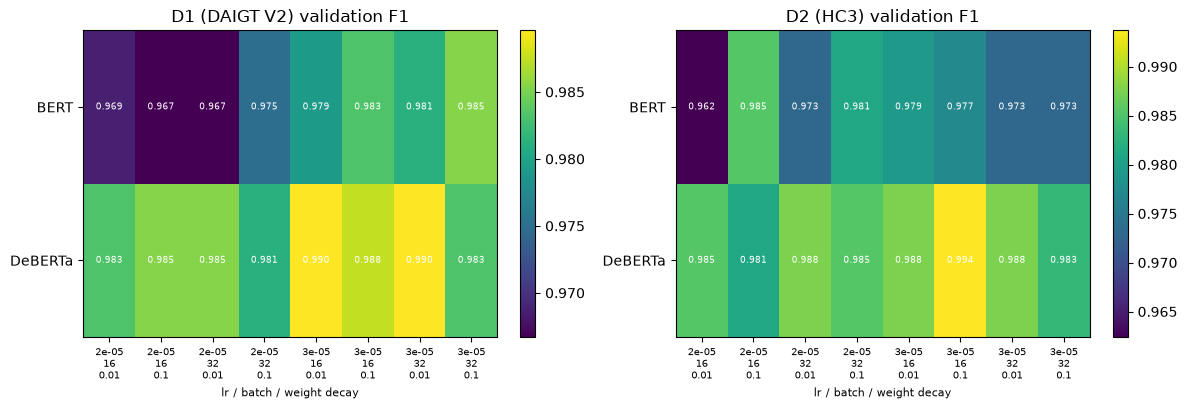

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, tag in zip(axes, DATASETS):
    piv = SWEEP[SWEEP.dataset==tag].pivot_table(
        index='model', columns=['lr','batch_size','weight_decay'], values='val_f1')
    im = ax.imshow(piv.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(piv.shape[1]))
    ax.set_xticklabels(['%g\n%d\n%g' % c for c in piv.columns], fontsize=7)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
    ax.set_title('%s (%s) validation F1' % (tag, DATASET_NAMES[tag]))
    ax.set_xlabel('lr / batch / weight decay', fontsize=8)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, '%.3f' % piv.values[i,j], ha='center', va='center',
                    color='w', fontsize=6.5)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(FIG_DIR / 'validation_f1_heatmap.png', dpi=150); plt.show()

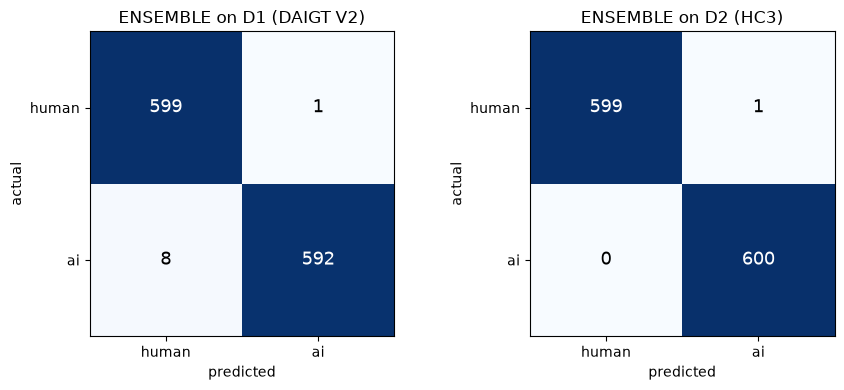

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, tag in zip(axes, DATASETS):
    cm = np.array(ENSEMBLE_DETAIL[tag]['confusion'])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='w' if cm[i,j] > cm.max()/2 else 'k', fontsize=13)
    ax.set_xticks([0,1]); ax.set_xticklabels(['human','ai'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['human','ai'])
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
    ax.set_title('ENSEMBLE on %s (%s)' % (tag, DATASET_NAMES[tag]))
plt.tight_layout(); plt.savefig(FIG_DIR / 'ensemble_confusion.png', dpi=150); plt.show()

In [19]:
summary = {
    'split': {tag: {k: int(len(v)) for k, v in SPLITS[tag].items()} for tag in DATASETS},
    'midterm_reproduced': True,
    'length_stats': LENGTH_STATS.to_dict('records'),
    'ensemble': ENSEMBLE_DETAIL,
    'seed_robustness': SEED_ROWS,
    'n_sweep_runs': len(sweep_runs),
    'transformers_version': transformers.__version__,
    'torch_version': torch.__version__,
    'gpu': torch.cuda.get_device_name(0),
}
atomic_write_json(FINAL_DIR / 'run_summary.json', summary)
print('Artefacts written to', FINAL_DIR)
for p in sorted(FINAL_DIR.glob('*.csv')) + sorted(FINAL_DIR.glob('*.json')):
    print('  ', p.name)
print('Figures:')
for p in sorted(FIG_DIR.glob('*.png')):
    print('  ', p.name)
print('\nBest test F1 per dataset:')
for tag in DATASETS:
    b = SWEEP[SWEEP.dataset==tag].sort_values('f1', ascending=False).iloc[0]
    print('  %s  %s lr=%g bs=%d wd=%g -> %.4f  (ensemble %.4f)' % (
        tag, b['model'], b['lr'], b['batch_size'], b['weight_decay'], b['f1'], ENSEMBLE_ROWS[tag][3]))

Artefacts written to /media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final
   table1_experiments.csv
   table2_combined.csv
   table3_contamination_sensitivity.csv
   run_summary.json
Figures:
   ensemble_confusion.png
   ensemble_weight_sweep.png
   token_length_distribution.png
   validation_f1_heatmap.png

Best test F1 per dataset:
  D1  DeBERTa lr=3e-05 bs=32 wd=0.01 -> 0.9942  (ensemble 0.9925)
  D2  DeBERTa lr=3e-05 bs=16 wd=0.1 -> 0.9992  (ensemble 0.9992)


## Section 8 — Data contamination sensitivityThe balanced samples were audited for duplicate documents after the split was fixed. Dataset 1 isclean: no document appears twice. Dataset 2 is not. HC3 is built by exploding lists of answers, and asmall number of answers are byte-identical to another answer in the corpus, so a few test documentsalso appear in the training portion.One class of duplicate is worth naming. Several HC3 entries stored as ChatGPT answers are not answersat all but API failure messages, for example `! Too many requests in 1 hour. Try again later.` Theseare labelled as machine-generated and repeat verbatim, which makes them both duplicated and triviallyseparable. That is a property of the corpus, not of the models being compared.The split is deliberately **not** changed to remove them, because it is the same split the midtermclassical models were scored on, and changing it would break the comparison that the combined tabledepends on. Instead the affected test rows are identified and every model is re-scored on theremaining clean test subset. Reporting both numbers shows the size of the effect rather thanasserting it is negligible. The contamination affects all models identically, so the ranking inTable 2 is unaffected either way.

In [20]:
import hashlib

CLEAN_MASK, CONTAM = {}, {}
for tag in DATASETS:
    df = DATA[tag]
    te = list(SPLITS[tag]['test'])
    seen = set(SPLITS[tag]['train'].tolist()) | set(SPLITS[tag]['val'].tolist())
    h = df['text'].map(lambda t: hashlib.md5(normalise(t).lower().encode()).hexdigest())
    by_hash = {}
    for i, v in h.items():
        by_hash.setdefault(v, []).append(i)
    leaked = [i for i in te if len(set(by_hash[h.loc[i]]) & seen) > 0]
    degen  = [i for i in te if len(normalise(df.loc[i, 'text'])) < 20]
    bad = set(leaked) | set(degen)
    CLEAN_MASK[tag] = np.array([i not in bad for i in te])
    CONTAM[tag] = {'test_size': len(te), 'leaked': len(leaked), 'degenerate': len(degen),
                   'excluded': len(bad), 'pct_of_test': round(100*len(bad)/len(te), 2),
                   'rows': sorted(int(x) for x in bad)}
    print('%s  test=%d  leaked=%d  degenerate=%d  excluded=%d (%.2f%% of test)' % (
        tag, len(te), len(leaked), len(degen), len(bad), CONTAM[tag]['pct_of_test']))
atomic_write_json(WORK_DIR / 'contamination_audit.json', CONTAM)

D1  test=1200  leaked=0  degenerate=0  excluded=0 (0.00% of test)
D2  test=1200  leaked=8  degenerate=0  excluded=8 (0.67% of test)


In [21]:
rows = []
for tag in DATASETS:
    te = list(SPLITS[tag]['test'])
    y_full = DATA[tag].loc[te, 'label'].values
    mask = CLEAN_MASK[tag]

    for name, rep in BEST_REP.items():
        yhat = CLASSICAL_PRED[(tag, name, rep)]
        full = weighted_metrics(y_full, yhat)[3]
        clean = weighted_metrics(y_full[mask], yhat[mask])[3]
        rows.append({'dataset': tag, 'Model': '%s (%s)' % (name, rep),
                     'F1 full test': round(full,4), 'F1 clean test': round(clean,4),
                     'delta': round(clean-full, 4)})

    for model_key, label in (('BERT','BERT'), ('DeBERTa','DeBERTa')):
        cand = [r for r in sweep_runs if r['dataset']==tag and r['model']==model_key]
        best = max(cand, key=lambda r: r['val']['f1'])
        z = load_probs(best['key'])
        yhat = z['test_probs'].argmax(1); y = z['test_labels']
        full = weighted_metrics(y, yhat)[3]
        clean = weighted_metrics(y[mask], yhat[mask])[3]
        rows.append({'dataset': tag, 'Model': label,
                     'F1 full test': round(full,4), 'F1 clean test': round(clean,4),
                     'delta': round(clean-full, 4)})

    d = ENSEMBLE_DETAIL[tag]
    pb, pdb = load_probs(d['member_bert']), load_probs(d['member_deberta'])
    mix = d['weight_bert']*pb['test_probs'] + (1-d['weight_bert'])*pdb['test_probs']
    yhat = mix.argmax(1); y = pb['test_labels']
    full = weighted_metrics(y, yhat)[3]
    clean = weighted_metrics(y[mask], yhat[mask])[3]
    rows.append({'dataset': tag, 'Model': 'ENSEMBLE',
                 'F1 full test': round(full,4), 'F1 clean test': round(clean,4),
                 'delta': round(clean-full, 4)})

SENSITIVITY = pd.DataFrame(rows)
SENSITIVITY.to_csv(FINAL_DIR / 'table3_contamination_sensitivity.csv', index=False)
display(SENSITIVITY)
worst = SENSITIVITY['delta'].abs().max()
print('\nLargest change in weighted F1 from excluding contaminated test rows: %.4f' % worst)
print('Model ranking within each dataset is unchanged: %s' % all(
    SENSITIVITY[SENSITIVITY.dataset==t].sort_values('F1 full test')['Model'].tolist() ==
    SENSITIVITY[SENSITIVITY.dataset==t].sort_values('F1 clean test')['Model'].tolist()
    for t in DATASETS))

,dataset,Model,F1 full test,F1 clean test,delta
0,D1,Naive Bayes (BoW),0.9566,0.9566,0.0000
1,D1,Logistic Regression (BoW),0.9825,0.9825,0.0000
2,D1,Support Vector Machine (TF-IDF),0.9875,0.9875,0.0000
3,D1,BERT,0.9908,0.9908,0.0000
4,D1,DeBERTa,0.9933,0.9933,0.0000
5,D1,ENSEMBLE,0.9925,0.9925,0.0000
6,D2,Naive Bayes (BoW),0.8583,0.8573,-0.0010
7,D2,Logistic Regression (BoW),0.9333,0.9328,-0.0004
8,D2,Support Vector Machine (TF-IDF),0.9083,0.9077,-0.0006
9,D2,BERT,0.9875,0.9874,-0.0001



Largest change in weighted F1 from excluding contaminated test rows: 0.0010
Model ranking within each dataset is unchanged: True


In [22]:
summary = json.load(open(FINAL_DIR / 'run_summary.json'))
summary['contamination'] = CONTAM
summary['sensitivity'] = SENSITIVITY.to_dict('records')
atomic_write_json(FINAL_DIR / 'run_summary.json', summary)
print('run_summary.json updated with the contamination audit and sensitivity results')
for p_ in sorted(FINAL_DIR.glob('*.csv')):
    print('  ', p_.name)

run_summary.json updated with the contamination audit and sensitivity results
   table1_experiments.csv
   table2_combined.csv
   table3_contamination_sensitivity.csv
